# Feature-Based Machine-Learning Model

This notebook develops a feature-based forecasting model for hourly appliance energy use.

The model combines:

- time-of-day and day-of-week information;
- lagged appliance-energy features;
- rolling-window statistics;
- selected indoor sensor variables;
- selected outdoor weather variables.

Histogram Gradient Boosting is used as a lightweight tree-based regression model. All target-derived features are created from historical observations only to reduce the risk of data leakage.

The model is evaluated using MAE, RMSE, MASE and forecast bias over the final 14-day test period.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FORECAST_DIR = PROJECT_ROOT / "outputs" / "forecasts"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

for directory in [
    FIGURE_DIR,
    FORECAST_DIR,
    METRICS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

DATA_FILE = (
    PROCESSED_DIR /
    "appliance_energy_hourly.csv"
)

print("Data file exists:", DATA_FILE.exists())

Data file exists: True


In [3]:
data = pd.read_csv(
    DATA_FILE,
    index_col="date",
    parse_dates=True
)

data = data.sort_index()

TARGET = "Appliances"

print("Dataset shape:", data.shape)

print(
    "Date range:",
    data.index.min(),
    "to",
    data.index.max()
)

Dataset shape: (3290, 28)
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


## Feature Engineering

The time series is transformed into a supervised-learning dataset using calendar, lagged, rolling-window, sensor and weather predictors.

Lag and rolling features are based only on previously observed appliance consumption. In particular, rolling statistics are calculated after shifting the target by one observation so that the current target value is not included in its own predictors.

In [5]:
features = data.copy()


# Time features


features["hour"] = features.index.hour

features["dayofweek"] = (
    features.index.dayofweek
)

features["is_weekend"] = (
    features["dayofweek"] >= 5
).astype(int)

features["hour_sin"] = np.sin(
    2 * np.pi
    * features["hour"]
    / 24
)

features["hour_cos"] = np.cos(
    2 * np.pi
    * features["hour"]
    / 24
)



# Lagged appliance-use features


for lag in [
    1,
    24,
    168
]:

    features[
        f"lag_{lag}"
    ] = (
        features[TARGET]
        .shift(lag)
    )



# Leakage-safe rolling features

shifted_target = (
    features[TARGET]
    .shift(1)
)

features[
    "roll_mean_24"
] = (
    shifted_target
    .rolling(24)
    .mean()
)

features[
    "roll_std_24"
] = (
    shifted_target
    .rolling(24)
    .std()
)


# Remove rows made incomplete by lagging
features = features.dropna()

print(
    "Feature dataset shape:",
    features.shape
)

Feature dataset shape: (3122, 38)


In [6]:
# Select predictor variables

feature_cols = [
    # Time
    "hour_sin",
    "hour_cos",
    "dayofweek",
    "is_weekend",

    # Target history
    "lag_1",
    "lag_24",
    "lag_168",

    # Rolling behaviour
    "roll_mean_24",
    "roll_std_24",

    # Indoor sensor variables
    "T1",
    "RH_1",

    # Outdoor weather
    "T_out",
    "RH_out"
]

feature_cols = [
    col
    for col in feature_cols
    if col in features.columns
]

print(
    "Number of features:",
    len(feature_cols)
)

print("\nFeatures used:")

for col in feature_cols:
    print("-", col)

Number of features: 13

Features used:
- hour_sin
- hour_cos
- dayofweek
- is_weekend
- lag_1
- lag_24
- lag_168
- roll_mean_24
- roll_std_24
- T1
- RH_1
- T_out
- RH_out


## Train-Test Split

The final 14 days of hourly observations are reserved as the test period, consistent with the forecasting design used for the benchmark and SARIMAX models.

The split is chronological to prevent future observations from being used during model training.

In [7]:
TEST_DAYS = 14
TEST_STEPS = TEST_DAYS * 24

train_ml = (
    features.iloc[
        :-TEST_STEPS
    ].copy()
)

test_ml = (
    features.iloc[
        -TEST_STEPS:
    ].copy()
)

X_train = (
    train_ml[
        feature_cols
    ]
)

y_train = (
    train_ml[TARGET]
)

X_test = (
    test_ml[
        feature_cols
    ]
)

y_test = (
    test_ml[TARGET]
)

print(
    "Training observations:",
    len(train_ml)
)

print(
    "Test observations:",
    len(test_ml)
)

print(
    "Train end:",
    train_ml.index.max()
)

print(
    "Test start:",
    test_ml.index.min()
)

Training observations: 2786
Test observations: 336
Train end: 2016-05-13 18:00:00
Test start: 2016-05-13 19:00:00


In [8]:
# Leakage checks

assert (
    train_ml.index.max()
    <
    test_ml.index.min()
)

assert (
    X_train.isna().sum().sum()
    == 0
)

assert (
    X_test.isna().sum().sum()
    == 0
)

print(
    "Chronological split and feature checks passed."
)
 

Chronological split and feature checks passed.


## Histogram Gradient Boosting Model

Histogram Gradient Boosting is used as the feature-based regression model because it can capture non-linear relationships and interactions among lagged appliance use, temporal features and environmental variables while remaining computationally efficient.

In [9]:
feature_model = (
    HistGradientBoostingRegressor(
        max_iter=120,
        learning_rate=0.06,
        max_leaf_nodes=20,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    )
)

feature_model.fit(
    X_train,
    y_train
)

print(
    "Feature-based model fitted successfully."
)

C:\Users\LOJANA-UOH\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\LOJANA-UOH\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\LOJANA-UOH\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\LOJANA-UOH\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~

Feature-based model fitted successfully.


In [10]:
feature_predictions = (
    feature_model.predict(
        X_test
    )
)

feature_predictions = pd.Series(
    feature_predictions,
    index=y_test.index,
    name="Feature_Model"
)

print(
    "Number of predictions:",
    len(feature_predictions)
)

Number of predictions: 336


In [12]:
def calculate_rmse(
    y_true,
    y_pred
):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def calculate_mase(
    y_true,
    y_pred,
    y_train,
    seasonality=24
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    y_train = np.asarray(
        y_train,
        dtype=float
    )

    scale = np.mean(
        np.abs(
            y_train[seasonality:]
            -
            y_train[:-seasonality]
        )
    )

    if scale == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                y_true
                - y_pred
            )
        )
        / scale
    )

In [13]:
feature_metrics = pd.DataFrame([
    {
        "Model":
            "HistGradientBoosting",

        "MAE":
            mean_absolute_error(
                y_test,
                feature_predictions
            ),

        "RMSE":
            calculate_rmse(
                y_test,
                feature_predictions
            ),

        "MASE":
            calculate_mase(
                y_test,
                feature_predictions,
                y_train,
                seasonality=24
            ),

        "Bias":
            np.mean(
                feature_predictions.values
                -
                y_test.values
            )
    }
])

feature_metrics.round(3)

,Model,MAE,RMSE,MASE,Bias
0,HistGradientBoosting,30.956,52.255,0.6,3.154


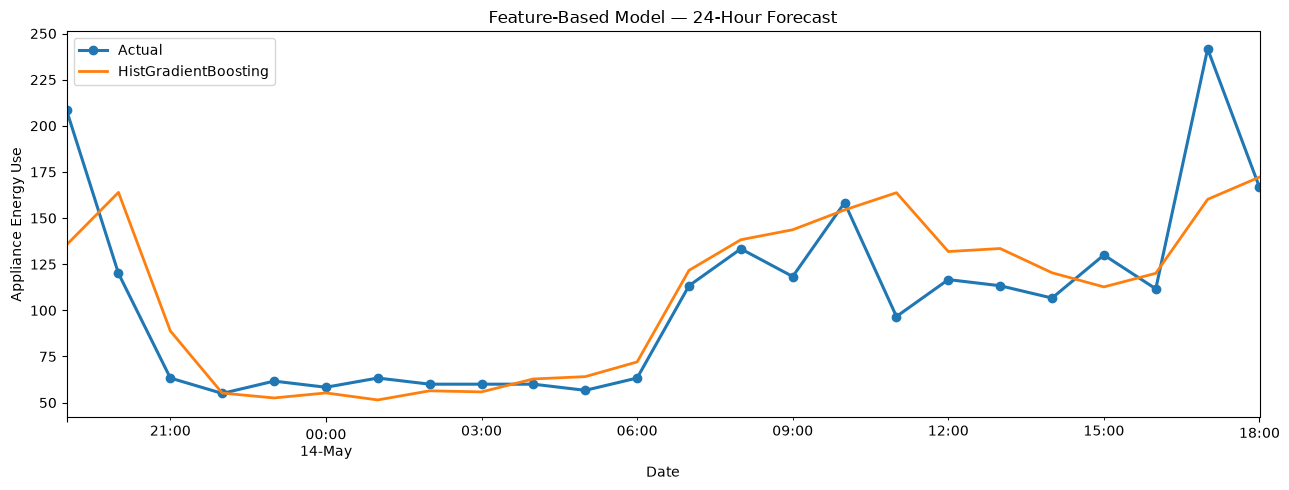

Figure saved: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\28_feature_model_24h_forecast.png


In [14]:
# 24-Hour Forecast Plot

first_24_index = (
    y_test.index[:24]
)

fig, ax = plt.subplots(
    figsize=(13, 5)
)

y_test.loc[
    first_24_index
].plot(
    ax=ax,
    label="Actual",
    marker="o",
    linewidth=2.2
)

feature_predictions.loc[
    first_24_index
].plot(
    ax=ax,
    label="HistGradientBoosting",
    linewidth=2
)

ax.set_title(
    "Feature-Based Model — 24-Hour Forecast"
)

ax.set_xlabel("Date")

ax.set_ylabel(
    "Appliance Energy Use"
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "28_feature_model_24h_forecast.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

In [15]:
feature_forecast_output = pd.DataFrame({
    "Actual": y_test,
    "Feature_Model":
        feature_predictions
})

feature_forecast_output.to_csv(
    FORECAST_DIR /
    "feature_model_forecast.csv"
)

feature_metrics.to_csv(
    METRICS_DIR /
    "feature_model_metrics.csv",
    index=False
)

print(
    "Feature-based forecasts and metrics saved successfully."
)


Feature-based forecasts and metrics saved successfully.


In [16]:
comparison_df = pd.DataFrame([
    {
        "Model": "Mean",
        "RMSE": 74.906,
        "MAE": 50.319
    },
    {
        "Model": "SARIMAX",
        "RMSE": 65.135,
        "MAE": 36.771
    },
    {
        "Model": "HistGradientBoosting",
        "RMSE": feature_metrics.loc[0, "RMSE"],
        "MAE": feature_metrics.loc[0, "MAE"]
    }
])

comparison_df

,Model,RMSE,MAE
0,Mean,74.906000,50.319000
1,SARIMAX,65.135000,36.771000
2,HistGradientBoosting,52.254518,30.956053


In [17]:
comparison_df.to_csv(
    METRICS_DIR / "overall_model_comparison.csv",
    index=False
)

print("Overall comparison saved.")


Overall comparison saved.
